In [4]:
pip install nltk

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.7 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 1.6 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 1.7 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import nltk

from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# Load dataset
df = pd.read_csv("F:/KDU/6th Semester/Dissertation/ML Model/Reviews.csv", encoding='latin-1')

# Combine title and text
df['Review'] = df['Title'].astype(str) + " " + df['Text'].astype(str)

# Drop missing values
df = df.dropna(subset=['Review'])

# Text Normalization 
df['clean_text'] = df['Review'].str.lower()

In [3]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Compute compound score
df['compound'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['compound']

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


0        0.9332
1        0.9716
2        0.9668
3        0.9552
4        0.9520
          ...  
16151    0.1655
16152    0.8722
16153   -0.3446
16154    0.4684
16155    0.7800
Name: compound, Length: 16156, dtype: float64

Sentiment
Positive    14382
Negative     1480
Neutral       294
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_5080\3243320973.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis')


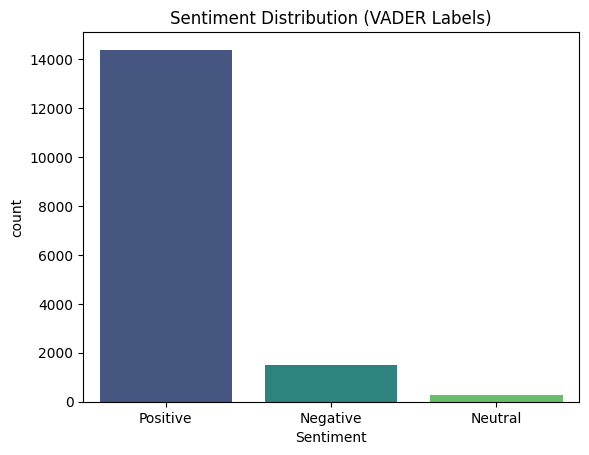

In [9]:
# Convert to categorical sentiment
df['Sentiment'] = df['compound'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)

# Check distribution
print(df['Sentiment'].value_counts())
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Sentiment Distribution (VADER Labels)')
plt.show()

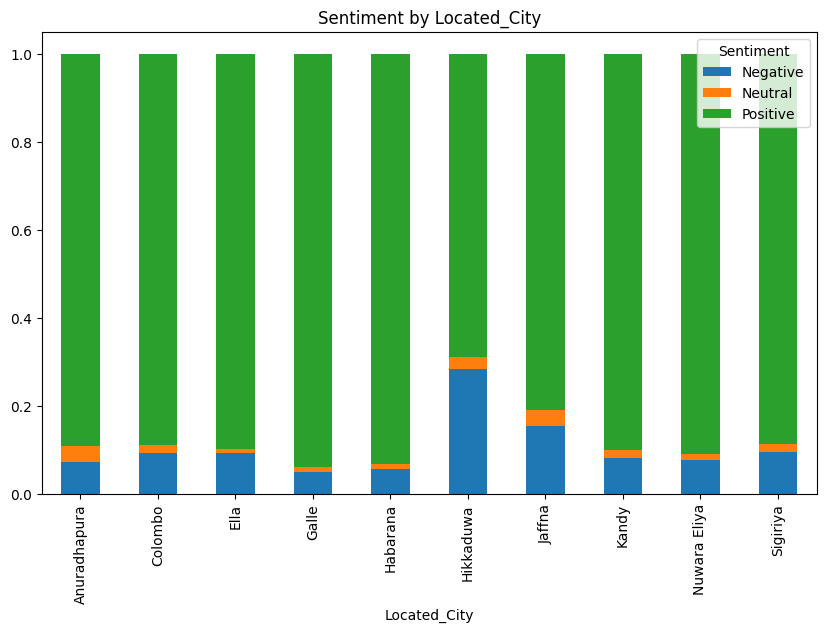

In [8]:
#Sentiment by Located_City
top_cities = df['Located_City'].value_counts().head(10).index
city_sent = df[df['Located_City'].isin(top_cities)].groupby('Located_City')['Sentiment'].value_counts(normalize=True).unstack()
city_sent.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sentiment by Located_City")
plt.show()

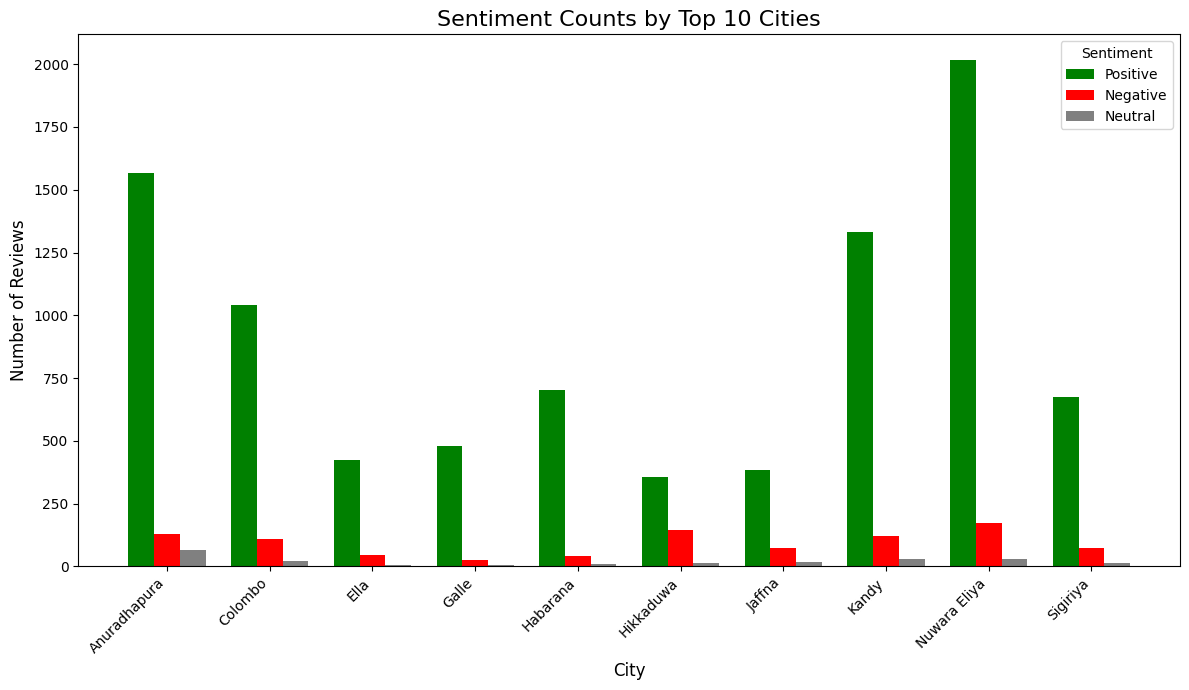

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Top 10 cities by review count
top_cities = df['Located_City'].value_counts().head(10).index

# Compute sentiment counts per city
city_sent_counts = df[df['Located_City'].isin(top_cities)].groupby('Located_City')['Sentiment'].value_counts().unstack().fillna(0)

# Prepare positions for grouped bars
cities = city_sent_counts.index
x = np.arange(len(cities))
width = 0.25  # width of each bar

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12,7))

ax.bar(x - width, city_sent_counts['Positive'], width, label='Positive', color='green')
ax.bar(x, city_sent_counts['Negative'], width, label='Negative', color='red')
ax.bar(x + width, city_sent_counts['Neutral'], width, label='Neutral', color='gray')

# Labels and title
ax.set_xlabel('City', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Sentiment Counts by Top 10 Cities', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=45, ha='right')
ax.legend(title='Sentiment')

plt.tight_layout()
plt.show()


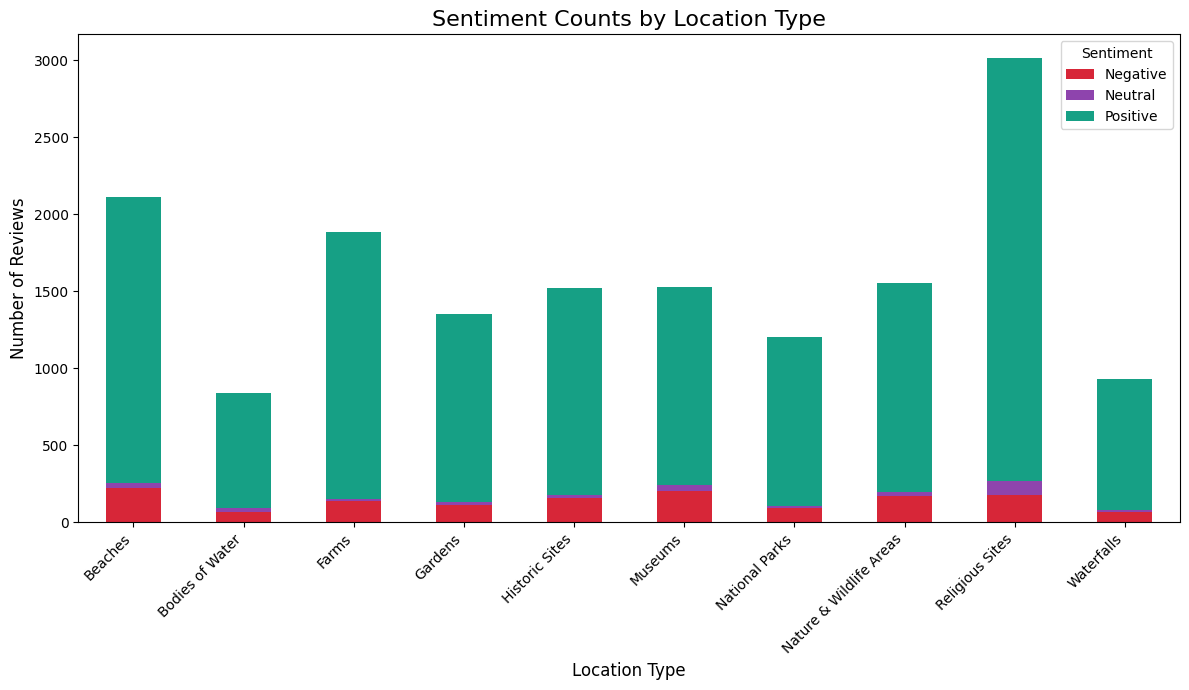

In [15]:
import matplotlib.pyplot as plt

# Top 10 locations
top_locations = df['Location_Type'].value_counts().head(10).index

# Compute sentiment counts per location
location_sentiment_counts = df[df['Location_Type'].isin(top_locations)].groupby('Location_Type')['Sentiment'].value_counts().unstack()

# Plot stacked bar chart
ax = location_sentiment_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=['#D72638', '#8E44AD', '#16A085']  # Negative, Neutral, Positive
)

plt.title("Sentiment Counts by Location Type", fontsize=16)
plt.xlabel("Location Type", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment', loc='upper right')
plt.tight_layout()
plt.show()



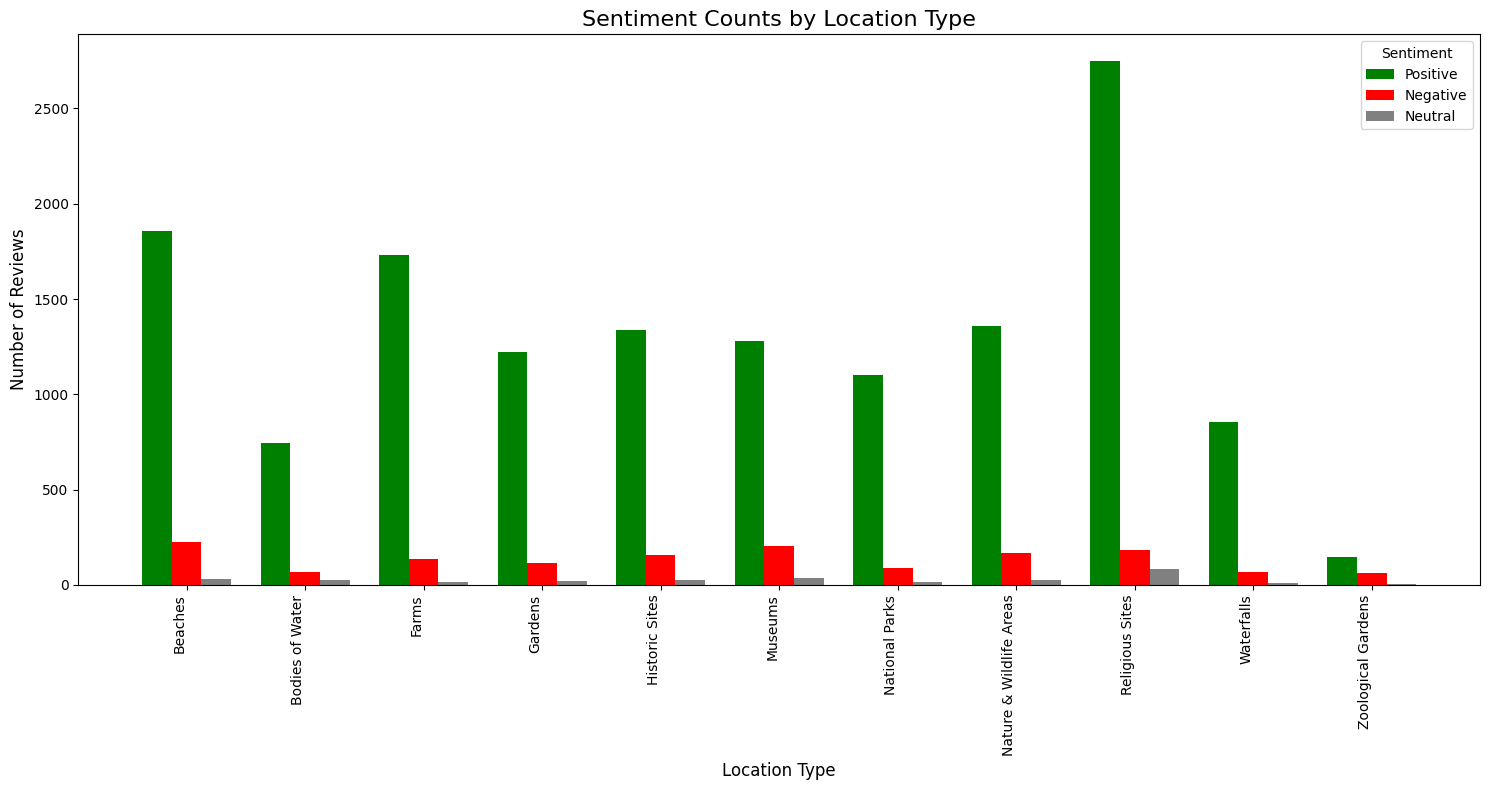

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Compute sentiment counts per location for all locations
location_sentiment_counts = df.groupby('Location_Type')['Sentiment'].value_counts().unstack().fillna(0)

# Prepare positions for grouped bars
locations = location_sentiment_counts.index
x = np.arange(len(locations))
width = 0.25  # width of each bar

# Plot grouped bars
fig, ax = plt.subplots(figsize=(15,8))

ax.bar(x - width, location_sentiment_counts['Positive'], width, label='Positive', color='green')
ax.bar(x, location_sentiment_counts['Negative'], width, label='Negative', color='red')
ax.bar(x + width, location_sentiment_counts['Neutral'], width, label='Neutral', color='gray')

# Labels and title
ax.set_xlabel('Location Type', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Sentiment Counts by Location Type', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(locations, rotation=90, ha='right')  # rotate for readability
ax.legend(title='Sentiment')

plt.tight_layout()
plt.show()



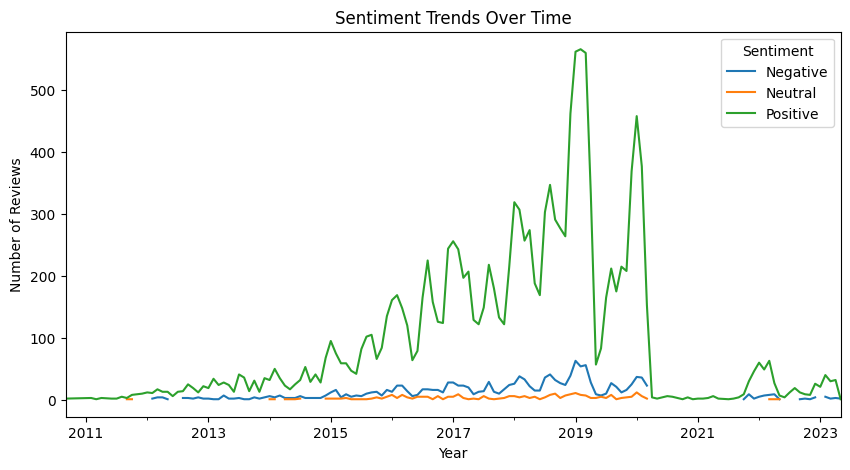

In [18]:
#Sentiment Over Time

df['Travel_Date'] = pd.to_datetime(df['Travel_Date'], errors='coerce')
df.dropna(subset=['Travel_Date'], inplace=True)  # Drop rows where Published_Date is NaT
df['Year'] = df['Travel_Date'].dt.to_period('M')

time_sent = df.groupby(['Year', 'Sentiment']).size().unstack()
time_sent.plot(kind='line', figsize=(10,5))
plt.title("Sentiment Trends Over Time")
plt.ylabel("Number of Reviews")
plt.show()

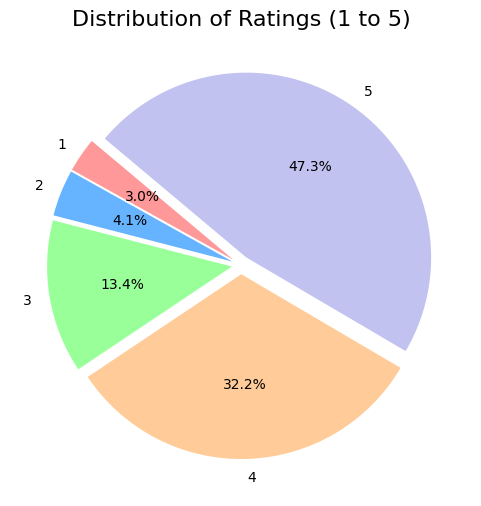

In [13]:
import matplotlib.pyplot as plt
rating_counts = df['Rating'].value_counts().sort_index()  # counts for 1,2,3,4,5

# Pie chart
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']  # optional colors for 1-5
plt.figure(figsize=(6,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=[0.05]*5)
plt.title("Distribution of Ratings (1 to 5)", fontsize=16)
plt.show()

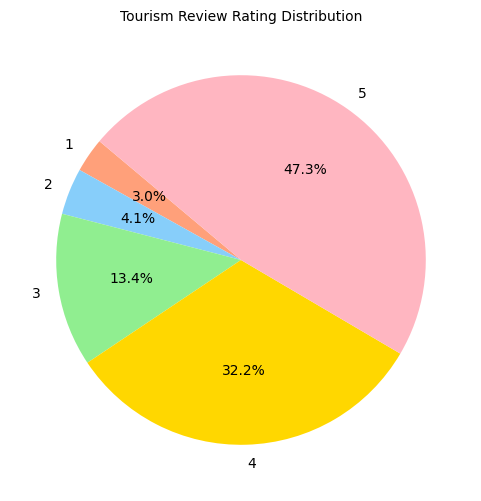

In [30]:
import matplotlib.pyplot as plt

rating_counts = df['Rating'].value_counts().sort_index()

# 5 distinct dark colours
colors = [
    '#FFA07A',  # Light Salmon
    '#87CEFA',  # Light Sky Blue
    '#90EE90',  # Light Green
    '#FFD700',  # Gold
    '#FFB6C1'   # Light Pink
]

plt.figure(figsize=(6,6))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=[0]*5
)

plt.title("Tourism Review Rating Distribution", fontsize=10)
plt.show()

